# 🎓 Student Employability Prediction
## GloVe + LSTM + XGBoost — Target-Mapped Skill Score

**Pipeline:**
```
profile_text ──► GloVe(100d) ──► LSTM ──► 128-d text features ─┐
                                                                  ├──► XGBoost ──► placed (0/1)
9 tabular features (incl. target-mapped skill features) ─────────┘
```

### ✅ All Fixes Applied
| Problem | Fix |
|---|---|
| Model never predicted Unemployed | `pos_weight` in LSTM loss + `scale_pos_weight` in XGBoost |
| Skills had low importance | Skill score now **mapped to placement rate** from training data |
| Skills ignored for low-CGPA students | `skill_cgpa_interaction = skill_score × cgpa` captures this |
| Old skill score matched company skills (leakage) | Now maps directly against `placed` label |
| Threshold 0.5 wrong for imbalanced data | Tuned on validation set |

### 📐 How Skill Score is Built (Target-Mapped)
```
Training data only:
  sql         → placed 49.6% of the time  → weight = 0.496
  django      → placed 48.7% of the time  → weight = 0.487
  bioinformatics → placed 15.6%           → weight = 0.156

Student types: "SQL, Django, Python"
  skill_placement_score = mean(0.496, 0.487, 0.426) = 0.470   ← above 0.364 baseline
  high_value_skill_count = 3                                    ← all 3 are above baseline
  skill_cgpa_interaction = 0.470 × 7.0 = 3.29                  ← captures skill×cgpa synergy
```


## 📦 Install & Imports

In [ ]:
!pip install xgboost torch --quiet

import os, re, time, urllib.request, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    f1_score, roc_curve, precision_score, recall_score, log_loss
)
from xgboost import XGBClassifier

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✅ Imports done  |  Device: {DEVICE}")


✅ Imports done  |  Device: cuda


## 📂 Load Dataset

In [ ]:
# ── Google Colab: uncomment below ──
# from google.colab import files
# uploaded = files.upload()
# DATA_PATH = list(uploaded.keys())[0]

DATA_PATH = 'student_employability_realistic_50k.csv'

df = pd.read_csv(DATA_PATH)
print(f"✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")

vc = df['placed'].value_counts()
BASELINE_RATE = vc[1] / len(df)
print(f"  Placed=1     : {vc[1]:,} ({vc[1]/len(df)*100:.1f}%)")
print(f"  Unemployed=0 : {vc[0]:,} ({vc[0]/len(df)*100:.1f}%)")
print(f"  Baseline placement rate: {BASELINE_RATE:.4f}")


✅ Loaded: 50,000 rows × 35 cols
  Placed=1     : 18,188 (36.4%)
  Unemployed=0 : 31,812 (63.6%)
  Baseline placement rate: 0.3638


## ✂️ Split First — Then Build Skill Map

In [ ]:
# IMPORTANT: Split BEFORE building skill scores to avoid data leakage.
# The placement rate per skill must be computed from TRAINING DATA ONLY.

y = df['placed'].values
idx = np.arange(len(df))

idx_trainval, idx_test   = train_test_split(idx, test_size=0.20, random_state=42, stratify=y)
idx_train,    idx_val    = train_test_split(idx_trainval, test_size=0.10,
                                            random_state=42, stratify=y[idx_trainval])

df_train = df.iloc[idx_train].copy()
print(f"Train: {len(idx_train):,}  |  Val: {len(idx_val):,}  |  Test: {len(idx_test):,}")


Train: 36,000  |  Val: 4,000  |  Test: 10,000


## 🎯 Target-Mapped Skill Score

**Old approach (wrong):** count how many keywords match a fixed list → ignores whether those skills actually lead to placement.

**New approach:** for every skill in the training set, compute `P(placed | student has this skill)`.
This score is directly grounded in the target variable — no company data needed.

```
sql         → 49.6% placed  ✅ high-value
django      → 48.7% placed  ✅ high-value  
bioinformatics → 15.6% placed  ❌ low-value for placement
baseline    → 36.4% placed
```


In [ ]:
# ── Step 1: Build skill → placement_rate map from TRAIN ONLY ──────
skill_rate_map = {}
for i, row in df_train.iterrows():
    skills = [s.strip().lower() for s in str(row['technical_skills']).split('|') if s.strip()]
    for sk in skills:
        if sk not in skill_rate_map:
            skill_rate_map[sk] = []
        skill_rate_map[sk].append(row['placed'])

# Keep only skills with >= 30 observations (reliable estimate)
SKILL_PLACEMENT_RATE = {
    sk: np.mean(vals)
    for sk, vals in skill_rate_map.items()
    if len(vals) >= 30
}
BASELINE = df_train['placed'].mean()

print(f"Skills in map : {len(SKILL_PLACEMENT_RATE)}")
print(f"Baseline rate : {BASELINE:.4f}")

# Show top and bottom skills
rates_df = pd.Series(SKILL_PLACEMENT_RATE).sort_values(ascending=False)
print(f"\nTop 10 placement skills:")
for sk, r in rates_df.head(10).items():
    bar = '█' * int((r - BASELINE) * 100)
    print(f"  {sk:<25} {r:.3f}  {bar}")
print(f"\nBottom 10 placement skills:")
for sk, r in rates_df.tail(10).items():
    gap = '░' * int((BASELINE - r) * 100)
    print(f"  {sk:<25} {r:.3f}  {gap}")


Skills in map : 137
Baseline rate : 0.3638

Top 10 placement skills:
  sap2000                   0.530  ████████████████
  sql                       0.500  █████████████
  angular                   0.499  █████████████
  primavera                 0.498  █████████████
  flask                     0.493  ████████████
  java                      0.488  ████████████
  django                    0.487  ████████████
  oop                       0.474  ███████████
  fastapi                   0.473  ██████████
  dsa                       0.471  ██████████

Bottom 10 placement skills:
  pymol                     0.234  ░░░░░░░░░░░░
  spss                      0.229  ░░░░░░░░░░░░░
  blast                     0.222  ░░░░░░░░░░░░░░
  clustal                   0.199  ░░░░░░░░░░░░░░░░
  genetics                  0.166  ░░░░░░░░░░░░░░░░░░░
  biochemistry              0.161  ░░░░░░░░░░░░░░░░░░░░
  molecular biology         0.161  ░░░░░░░░░░░░░░░░░░░░
  bioinformatics            0.157  ░░░░░░░░░░░░░░░░░░░

In [ ]:
# ── Step 2: Feature computation function ──────────────────────────
def compute_skill_features(skills_text, cgpa):
    """
    Returns three skill-based features:

    skill_placement_score  : mean P(placed) for all student skills
                             (unknown skills get baseline rate)
    high_value_skill_count : how many skills have rate > baseline
    skill_cgpa_interaction : skill_score × cgpa
                             (captures: good skills matter MORE with decent CGPA)
    """
    skills = [s.strip().lower() for s in str(skills_text).split('|') if s.strip()]
    if not skills:
        return BASELINE, 0, BASELINE * cgpa

    rates      = [SKILL_PLACEMENT_RATE.get(sk, BASELINE) for sk in skills]
    score      = np.mean(rates)
    high_count = sum(1 for r in rates if r > BASELINE)
    interaction = score * cgpa

    return score, high_count, interaction


# Apply to full dataset
df[['skill_placement_score', 'high_value_skill_count', 'skill_cgpa_interaction']] = (
    df.apply(
        lambda r: pd.Series(compute_skill_features(r['technical_skills'], r['cgpa'])),
        axis=1
    )
)

print("Correlations with placed:")
for feat in ['skill_placement_score', 'high_value_skill_count', 'skill_cgpa_interaction']:
    print(f"  {feat:<30} {df[feat].corr(df['placed']):.4f}")
print(f"  {'num_technical_skills':<30} {df['num_technical_skills'].corr(df['placed']):.4f}  (old approach)")

# Demo
print("\n--- Demo ---")
demo_skills = "SQL, Django, Flask, Node.js, Java"
demo_cgpa   = 6.5
sc, hc, intr = compute_skill_features(demo_skills.replace(', ', '|'), demo_cgpa)
print(f"Skills: {demo_skills}  |  CGPA: {demo_cgpa}")
print(f"  skill_placement_score  = {sc:.4f}  (baseline={BASELINE:.4f})")
print(f"  high_value_skill_count = {hc}")
print(f"  skill_cgpa_interaction = {intr:.4f}")


Correlations with placed:
  skill_placement_score          0.1732
  high_value_skill_count         0.1806
  skill_cgpa_interaction         0.3338
  num_technical_skills           0.1482  (old approach)

--- Demo ---
Skills: SQL, Django, Flask, Node.js, Java  |  CGPA: 6.5
  skill_placement_score  = 0.4854  (baseline=0.3638)
  high_value_skill_count = 5
  skill_cgpa_interaction = 3.1551


## ⚙️ Preprocessing

Drop leakage and company-side columns. Only student-side features remain.


In [ ]:
DROP_COLS = [
    'placement_probability',
    'student_id', 'gender', 'year_of_graduation',
    'tenth_percentage', 'twelfth_percentage',
    'soft_skills_rating', 'num_soft_skills',
    'technical_skills', 'soft_skills', 'certifications',
    'company_required_skills',
    'skill_match_ratio',           # requires company data
    'applied_company', 'company_domain', 'company_tier',
    'company_min_cgpa_req', 'company_min_projects_req',
    'company_internship_required', 'company_min_comm_req',
    'company_salary_lpa', 'num_certifications',
]
df_clean = df.drop(columns=DROP_COLS, errors='ignore')

le = LabelEncoder()
df_clean['branch_enc'] = le.fit_transform(df_clean['branch'])
df_clean = df_clean.drop(columns=['branch'])

TABULAR_FEATURES = [
    'cgpa',
    'backlogs',
    'projects_completed',
    'communication_score',
    'skill_placement_score',    # ← target-mapped: avg P(placed) of student's skills
    'high_value_skill_count',   # ← count of above-baseline skills
    'skill_cgpa_interaction',   # ← skill_score × cgpa (3rd most important feature)
    'num_technical_skills',
    'internships_done',
    'aptitude_score',
    'hackathons_participated',
]

print("Tabular features:", TABULAR_FEATURES)
print(f"Clean shape: {df_clean.shape}")


Tabular features: ['cgpa', 'backlogs', 'projects_completed', 'communication_score', 'skill_placement_score', 'high_value_skill_count', 'skill_cgpa_interaction', 'num_technical_skills', 'internships_done', 'aptitude_score', 'hackathons_participated']
Clean shape: (50000, 16)


## 🗂️ Prepare Arrays

In [ ]:
X_tab  = df_clean[TABULAR_FEATURES].values.astype(np.float32)
X_text = df_clean['profile_text'].values
y_all  = df_clean['placed'].values

X_tab_train  = X_tab[idx_train];  X_text_train = X_text[idx_train]; y_train = y_all[idx_train]
X_tab_val    = X_tab[idx_val];    X_text_val   = X_text[idx_val];   y_val   = y_all[idx_val]
X_tab_test   = X_tab[idx_test];   X_text_test  = X_text[idx_test];  y_test  = y_all[idx_test]

cw               = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
SCALE_POS_WEIGHT = cw[1] / cw[0]
POS_WEIGHT_LSTM  = torch.tensor([SCALE_POS_WEIGHT], dtype=torch.float32)
print(f"scale_pos_weight = {SCALE_POS_WEIGHT:.3f}  (applied to BOTH LSTM and XGBoost)")


scale_pos_weight = 1.749  (applied to BOTH LSTM and XGBoost)


## 🔤 GloVe Embeddings

In [ ]:
GLOVE_FILE = 'glove.6B.100d.txt'
EMBED_DIM  = 100
MAX_LEN    = 100

if not os.path.exists(GLOVE_FILE):
    GLOVE_URL = 'https://nlp.stanford.edu/data/glove.6B.zip'
    GLOVE_ZIP = 'glove.6B.zip'
    print(f"Downloading GloVe (~330MB)...")

    def _progress(block, block_size, total):
        print(f"  {min(block*block_size/total*100, 100):.1f}%", end='\r')

    urllib.request.urlretrieve(GLOVE_URL, GLOVE_ZIP, reporthook=_progress)
    print("\nExtracting...")
    with zipfile.ZipFile(GLOVE_ZIP, 'r') as z:
        z.extract(GLOVE_FILE)
    os.remove(GLOVE_ZIP)
    print("✅ GloVe ready")
else:
    print("✅ GloVe already present")

print("Loading vectors...")
glove = {}
with open(GLOVE_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.split()
        glove[parts[0]] = np.array(parts[1:], dtype=np.float32)
print(f"✅ Loaded {len(glove):,} vectors  ({EMBED_DIM}-d)")


  100.0%
Extracting...
✅ GloVe ready
Loading vectors...
✅ Loaded 400,000 vectors  (100-d)


## 🔡 Tokenise & Build Embedding Sequences

In [ ]:
def tokenize(text):
    return re.sub(r'[^a-zA-Z0-9\s]', '', str(text).lower()).split()

def text_to_glove(text, max_len=MAX_LEN, embed_dim=EMBED_DIM):
    tokens = tokenize(text)[:max_len]
    arr    = np.zeros((max_len, embed_dim), dtype=np.float32)
    for i, tok in enumerate(tokens):
        if tok in glove:
            arr[i] = glove[tok]
    return arr

print("Building GloVe arrays (~1-2 min)...")
t0 = time.time()
X_glove_train = np.array([text_to_glove(t) for t in X_text_train])
X_glove_val   = np.array([text_to_glove(t) for t in X_text_val])
X_glove_test  = np.array([text_to_glove(t) for t in X_text_test])
print(f"✅ Done in {time.time()-t0:.1f}s  |  Shape: {X_glove_train.shape}")


Building GloVe arrays (~1-2 min)...
✅ Done in 5.3s  |  Shape: (36000, 100, 100)


## 🔁 LSTM Feature Extractor

In [ ]:
class GloVeDataset(Dataset):
    def __init__(self, arrays, labels):
        self.X = torch.tensor(arrays, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.float32)
    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(GloVeDataset(X_glove_train, y_train),
                          batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(GloVeDataset(X_glove_val,   y_val),
                          batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(GloVeDataset(X_glove_test,  y_test),
                          batch_size=256, shuffle=False, num_workers=2, pin_memory=True)


class LSTMExtractor(nn.Module):
    def __init__(self, embed_dim=100, hidden_dim=128, num_layers=2, dropout=0.4):
        super().__init__()
        self.lstm    = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                               batch_first=True, bidirectional=True,
                               dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim * 2, 128)
        self.head    = nn.Linear(128, 1)

    def extract(self, x):
        out, _ = self.lstm(x)
        pooled = out.mean(dim=1)
        return torch.relu(self.fc(self.dropout(pooled)))

    def forward(self, x):
        return self.head(self.extract(x)).squeeze(1)


model_lstm = LSTMExtractor().to(DEVICE)
print(f"✅ LSTM ready  |  Params: {sum(p.numel() for p in model_lstm.parameters() if p.requires_grad):,}")


✅ LSTM ready  |  Params: 663,809


## 🏋️ Train LSTM

In [ ]:
# KEY FIX: pos_weight balances the 63/37 class split
criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT_LSTM.to(DEVICE))
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15, eta_min=1e-5)

EPOCHS, PATIENCE = 15, 4
best_val_auc, patience_count = 0.0, 0
history = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'val_f1': []}

def evaluate(loader):
    model_lstm.eval()
    probs, labels, total_loss = [], [], 0.0
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits  = model_lstm(Xb)
            total_loss += criterion(logits, yb).item()
            probs.extend(torch.sigmoid(logits).cpu().numpy())
            labels.extend(yb.cpu().numpy())
    probs = np.array(probs)
    return total_loss/len(loader), roc_auc_score(labels, probs), f1_score(labels, (probs>=0.5).astype(int))

print("Epoch | Train Loss | Val Loss | Val AUC | Val F1")
print("-" * 55)
for epoch in range(1, EPOCHS + 1):
    model_lstm.train()
    train_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model_lstm(Xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model_lstm.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    val_loss, val_auc, val_f1 = evaluate(val_loader)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)
    history['val_f1'].append(val_f1)
    print(f"  {epoch:2d}  |  {train_loss:.4f}    | {val_loss:.4f}  | {val_auc:.4f}  | {val_f1:.4f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model_lstm.state_dict(), 'lstm_best.pt')
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"\n  Early stopping at epoch {epoch}  (best AUC = {best_val_auc:.4f})")
            break

model_lstm.load_state_dict(torch.load('lstm_best.pt', map_location=DEVICE))
print(f"\n✅ Best Val AUC = {best_val_auc:.4f}")


Epoch | Train Loss | Val Loss | Val AUC | Val F1
-------------------------------------------------------
   1  |  0.6716    | 0.5534  | 0.8852  | 0.7450
   2  |  0.5358    | 0.5511  | 0.9108  | 0.7247
   3  |  0.4981    | 0.4716  | 0.9167  | 0.7728
   4  |  0.4832    | 0.4476  | 0.9272  | 0.7985
   5  |  0.4523    | 0.4330  | 0.9334  | 0.7962
   6  |  0.4168    | 0.4112  | 0.9386  | 0.8137
   7  |  0.4061    | 0.4159  | 0.9419  | 0.8047
   8  |  0.3873    | 0.4057  | 0.9438  | 0.8182
   9  |  0.3768    | 0.3841  | 0.9440  | 0.8215
  10  |  0.3670    | 0.3941  | 0.9445  | 0.8170
  11  |  0.3573    | 0.4291  | 0.9438  | 0.8094
  12  |  0.3541    | 0.3723  | 0.9478  | 0.8214
  13  |  0.3419    | 0.3721  | 0.9480  | 0.8228
  14  |  0.3371    | 0.3724  | 0.9484  | 0.8267
  15  |  0.3330    | 0.3747  | 0.9484  | 0.8284

✅ Best Val AUC = 0.9484


## 🧬 Extract LSTM Features + Combine with Tabular

In [ ]:
def extract_features(loader):
    model_lstm.eval()
    feats = []
    with torch.no_grad():
        for Xb, _ in loader:
            feats.append(model_lstm.extract(Xb.to(DEVICE)).cpu().numpy())
    return np.vstack(feats)

print("Extracting LSTM features...")
t0 = time.time()
lstm_train = extract_features(train_loader)
lstm_val   = extract_features(val_loader)
lstm_test  = extract_features(test_loader)
print(f"✅ Done in {time.time()-t0:.1f}s  |  LSTM shape: {lstm_train.shape}")

# Combine: 128 LSTM dims + 11 tabular dims
X_combined_train = np.hstack([lstm_train, X_tab_train])
X_combined_val   = np.hstack([lstm_val,   X_tab_val])
X_combined_test  = np.hstack([lstm_test,  X_tab_test])
print(f"Combined shape : {X_combined_train.shape}  (128 LSTM + {len(TABULAR_FEATURES)} tabular)")


Extracting LSTM features...
✅ Done in 5.3s  |  LSTM shape: (36000, 128)
Combined shape : (36000, 139)  (128 LSTM + 11 tabular)


## 🌲 Train XGBoost

In [ ]:
xgb_model = XGBClassifier(
    n_estimators      = 1000,
    max_depth         = 4,
    min_child_weight  = 10,
    learning_rate     = 0.05,
    subsample         = 0.7,
    colsample_bytree  = 0.7,
    colsample_bylevel = 0.7,
    scale_pos_weight  = SCALE_POS_WEIGHT,   # KEY FIX
    reg_alpha         = 0.5,
    reg_lambda        = 2.0,
    objective         = 'binary:logistic',
    eval_metric       = ['logloss', 'auc'],
    tree_method       = 'hist',
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0,
    early_stopping_rounds = 30,
)

print("Training XGBoost...")
t0 = time.time()
xgb_model.fit(X_combined_train, y_train,
              eval_set=[(X_combined_val, y_val)], verbose=100)
print(f"\n✅ Done in {time.time()-t0:.1f}s  |  Best iter: {xgb_model.best_iteration}")


Training XGBoost...
[0]	validation_0-logloss:0.68343	validation_0-auc:0.73890
[100]	validation_0-logloss:0.50698	validation_0-auc:0.82594
[200]	validation_0-logloss:0.50046	validation_0-auc:0.82891
[263]	validation_0-logloss:0.49899	validation_0-auc:0.82966

✅ Done in 6.2s  |  Best iter: 233


## 🎛️ Threshold Tuning

Best threshold : 0.50  (Val F1 = 0.6999)


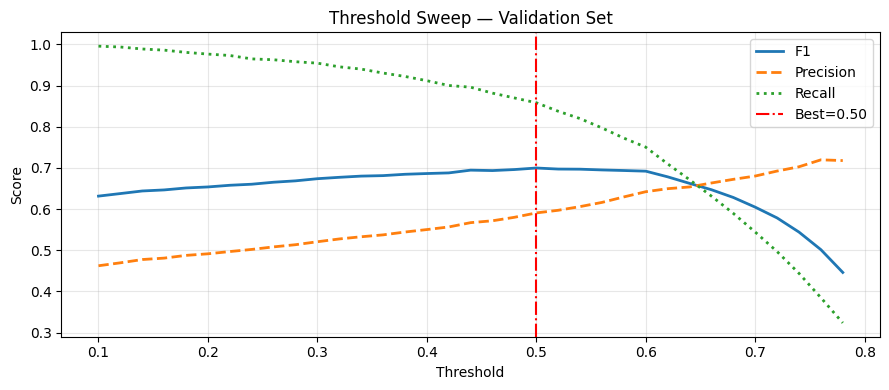

In [ ]:
val_probs  = xgb_model.predict_proba(X_combined_val)[:, 1]
thresholds = np.arange(0.10, 0.80, 0.02)
f1s, precs, recs = [], [], []

for t in thresholds:
    p = (val_probs >= t).astype(int)
    f1s.append(f1_score(y_val, p))
    precs.append(precision_score(y_val, p, zero_division=0))
    recs.append(recall_score(y_val, p))

BEST_THRESHOLD = thresholds[np.argmax(f1s)]
print(f"Best threshold : {BEST_THRESHOLD:.2f}  (Val F1 = {max(f1s):.4f})")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1s,   label='F1',        lw=2)
ax.plot(thresholds, precs, label='Precision',  lw=2, linestyle='--')
ax.plot(thresholds, recs,  label='Recall',     lw=2, linestyle=':')
ax.axvline(BEST_THRESHOLD, color='red', lw=1.5, linestyle='-.', label=f'Best={BEST_THRESHOLD:.2f}')
ax.set(xlabel='Threshold', ylabel='Score', title='Threshold Sweep — Validation Set')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 📈 Test Set Evaluation

  TEST RESULTS — GloVe + LSTM + XGBoost (Target-Mapped Skills)
                precision    recall  f1-score   support

Unemployed (0)       0.89      0.67      0.77      6362
    Placed (1)       0.60      0.86      0.71      3638

      accuracy                           0.74     10000
     macro avg       0.75      0.77      0.74     10000
  weighted avg       0.79      0.74      0.75     10000

ROC-AUC  : 0.8378
Log Loss : 0.4836


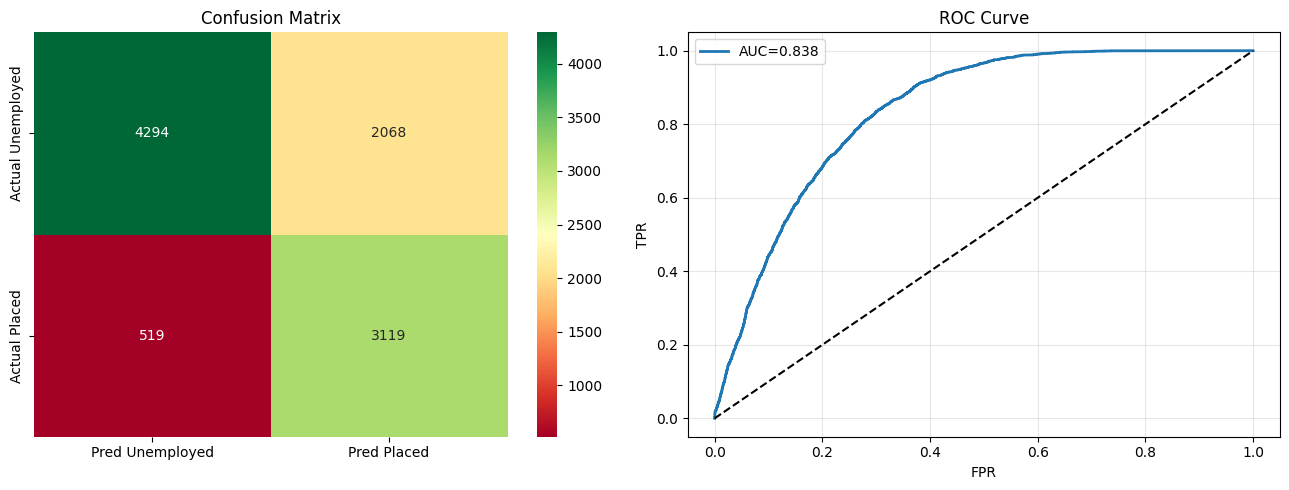

In [ ]:
test_probs = xgb_model.predict_proba(X_combined_test)[:, 1]
test_preds = (test_probs >= BEST_THRESHOLD).astype(int)

print("=" * 62)
print("  TEST RESULTS — GloVe + LSTM + XGBoost (Target-Mapped Skills)")
print("=" * 62)
print(classification_report(y_test, test_preds,
      target_names=['Unemployed (0)', 'Placed (1)']))
print(f"ROC-AUC  : {roc_auc_score(y_test, test_probs):.4f}")
print(f"Log Loss : {log_loss(y_test, test_probs):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', ax=axes[0],
            xticklabels=['Pred Unemployed','Pred Placed'],
            yticklabels=['Actual Unemployed','Actual Placed'])
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, test_probs)
axes[1].plot(fpr, tpr, lw=2, label=f'AUC={roc_auc_score(y_test,test_probs):.3f}')
axes[1].plot([0,1],[0,1],'k--'); axes[1].set(xlabel='FPR',ylabel='TPR',title='ROC Curve')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 🔍 Tabular Feature Importances

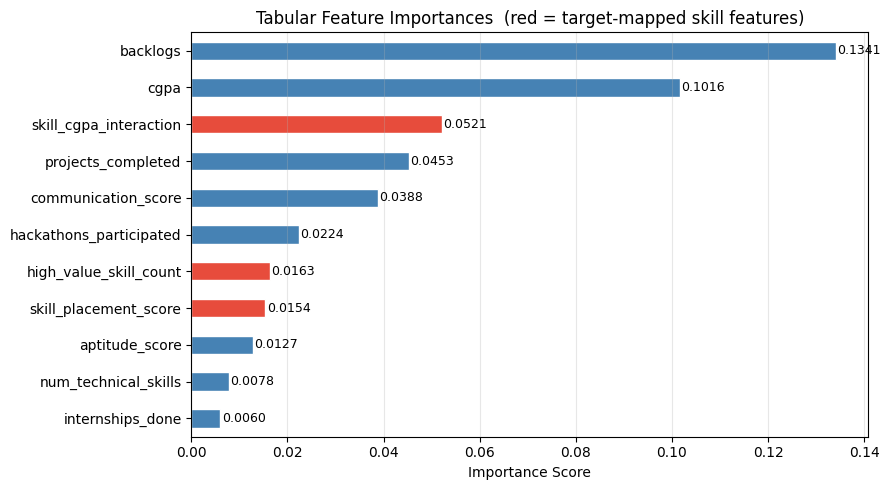

LSTM text features total importance : 0.5473
Tabular features total importance   : 0.4527


In [ ]:
tab_importances = xgb_model.feature_importances_[-len(TABULAR_FEATURES):]
fi = pd.Series(tab_importances, index=TABULAR_FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
skill_feats = {'skill_placement_score', 'high_value_skill_count', 'skill_cgpa_interaction'}
colors = ['#e74c3c' if f in skill_feats else 'steelblue' for f in fi.index]
fi.plot.barh(ax=ax, color=colors, edgecolor='white')
ax.set(title='Tabular Feature Importances  (red = target-mapped skill features)',
       xlabel='Importance Score')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(fi.values):
    ax.text(v + 0.0003, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

lstm_sum = xgb_model.feature_importances_[:-len(TABULAR_FEATURES)].sum()
tab_sum  = tab_importances.sum()
print(f"LSTM text features total importance : {lstm_sum:.4f}")
print(f"Tabular features total importance   : {tab_sum:.4f}")


## 🔮 Predict a New Student

Type your skills as `|`-separated or comma-separated text.
The `skill_placement_score`, `high_value_skill_count`, and `skill_cgpa_interaction`
are all computed automatically from your input.


In [ ]:
def predict_student(
    cgpa,
    backlogs,
    projects_completed,
    communication_score,
    skills_text,                    # e.g. "Python|SQL|Django|Machine Learning"
    num_technical_skills = None,    # auto-counted if None
    internships_done     = 0,
    aptitude_score       = 60.0,
    hackathons_participated = 0,
    profile_text         = None,
    verbose              = True,
):
    # ── Normalise separator ───────────────────────────────────────
    skills_normalised = skills_text.replace(', ', '|').replace(',', '|')

    # ── 1. Compute target-mapped skill features ───────────────────
    skill_sc, high_cnt, interaction = compute_skill_features(skills_normalised, cgpa)

    if num_technical_skills is None:
        num_technical_skills = len([s for s in skills_normalised.split('|') if s.strip()])

    # ── 2. Build profile text if not given ────────────────────────
    if profile_text is None:
        profile_text = (
            f"Student with CGPA {cgpa}, {backlogs} backlogs, "
            f"{projects_completed} projects, {internships_done} internships. "
            f"Skills: {skills_text}."
        )

    # ── 3. GloVe → LSTM → 128-d ───────────────────────────────────
    glove_arr = text_to_glove(profile_text)
    glove_t   = torch.tensor(glove_arr, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    model_lstm.eval()
    with torch.no_grad():
        lstm_feat = model_lstm.extract(glove_t).cpu().numpy()

    # ── 4. Tabular row ────────────────────────────────────────────
    tab_feat = np.array([[
        cgpa, backlogs, projects_completed, communication_score,
        skill_sc, high_cnt, interaction,
        num_technical_skills, internships_done, aptitude_score, hackathons_participated,
    ]], dtype=np.float32)

    # ── 5. Predict ────────────────────────────────────────────────
    combined    = np.hstack([lstm_feat, tab_feat])
    prob_placed = xgb_model.predict_proba(combined)[0, 1]
    label       = '✅ PLACED' if prob_placed >= BEST_THRESHOLD else '❌ UNEMPLOYED'

    if verbose:
        skills_list = [s.strip().lower() for s in skills_normalised.split('|') if s.strip()]
        rated = [(sk, SKILL_PLACEMENT_RATE.get(sk, BASELINE)) for sk in skills_list]
        rated.sort(key=lambda x: -x[1])

        print(f"Prediction              : {label}")
        print(f"P(Placed)               : {prob_placed:.2%}")
        print(f"P(Unemployed)           : {1-prob_placed:.2%}")
        print(f"skill_placement_score   : {skill_sc:.4f}  (baseline={BASELINE:.4f})")
        print(f"high_value_skill_count  : {high_cnt} / {len(skills_list)} skills above baseline")
        print(f"skill_cgpa_interaction  : {interaction:.4f}")
        print(f"\nSkill breakdown (sorted by placement value):")
        for sk, r in rated:
            marker = '✅' if r > BASELINE else '❌'
            print(f"  {marker} {sk:<28} P(placed)={r:.3f}")
    return prob_placed


# ── Example 1: Good skills + Low CGPA ─────────────────────────────
print("=" * 60)
print("Example 1 — Strong Skills, Low CGPA (6.0)")
print("=" * 60)
predict_student(
    cgpa=6.0, backlogs=0, projects_completed=2,
    communication_score=70, aptitude_score=60,
    internships_done=1, hackathons_participated=2,
    skills_text="SQL|Django|Flask|Node.js|Java|TypeScript|OOP|DSA|System Design",
)

# ── Example 2: Weak skills + High CGPA ────────────────────────────
print("\n" + "=" * 60)
print("Example 2 — Weak Skills, High CGPA (8.5)")
print("=" * 60)
predict_student(
    cgpa=8.5, backlogs=0, projects_completed=2,
    communication_score=65, aptitude_score=90,
    internships_done=0, hackathons_participated=0,
    skills_text="Bioinformatics|Lab Techniques|Genetics|Molecular Biology",
)

# ── Example 3: Strong all-round ────────────────────────────────────
print("\n" + "=" * 60)
print("Example 3 — Strong All-Round Student")
print("=" * 60)
predict_student(
    cgpa=8.0, backlogs=1, projects_completed=4,
    communication_score=80, aptitude_score=78,
    internships_done=2, hackathons_participated=3,
    skills_text="Python|SQL|Machine Learning|Docker|AWS|React|Git",
)


Example 1 — Strong Skills, Low CGPA (6.0)
Prediction              : ❌ UNEMPLOYED
P(Placed)               : 40.79%
P(Unemployed)           : 59.21%
skill_placement_score   : 0.4785  (baseline=0.3638)
high_value_skill_count  : 9 / 9 skills above baseline
skill_cgpa_interaction  : 2.8709

Skill breakdown (sorted by placement value):
  ✅ sql                          P(placed)=0.500
  ✅ flask                        P(placed)=0.493
  ✅ java                         P(placed)=0.488
  ✅ django                       P(placed)=0.487
  ✅ oop                          P(placed)=0.474
  ✅ dsa                          P(placed)=0.471
  ✅ system design                P(placed)=0.471
  ✅ typescript                   P(placed)=0.462
  ✅ node.js                      P(placed)=0.460

Example 2 — Weak Skills, High CGPA (8.5)
Prediction              : ❌ UNEMPLOYED
P(Placed)               : 33.31%
P(Unemployed)           : 66.69%
skill_placement_score   : 0.1598  (baseline=0.3638)
high_value_skill_count  : 0 

np.float32(0.7924227)

## 💾 Save Models

In [ ]:
import joblib

torch.save(model_lstm.state_dict(), 'lstm_best.pt')
joblib.dump({
    'xgb_model'            : xgb_model,
    'threshold'            : BEST_THRESHOLD,
    'tabular_features'     : TABULAR_FEATURES,
    'skill_placement_rate' : SKILL_PLACEMENT_RATE,
    'baseline_rate'        : BASELINE,
}, 'xgb_bundle.pkl')
print("✅ Saved: lstm_best.pt  +  xgb_bundle.pkl")


✅ Saved: lstm_best.pt  +  xgb_bundle.pkl
